In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("../data/loan_approval_dataset.csv")
df.columns = df.columns.str.strip()

X = df.drop(columns=["loan_id", "loan_status"])
y = df["loan_status"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    X[col] = X[col].str.strip()

y = y.str.strip()

X_encoded = X.copy()
feature_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    feature_encoders[col] = le

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Data prepared successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Data prepared successfully.
X_train shape: (3415, 11)
X_test shape: (854, 11)


/var/folders/93/089f0j5140590b91wt26qzwm0000gn/T/ipykernel_18571/2338558402.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [3]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [4]:
y_pred = log_model.predict(X_test)

print("First 10 predictions:", y_pred[:10])
print("First 10 actual values:", y_test[:10])

First 10 predictions: [0 0 0 0 0 1 0 0 0 0]
First 10 actual values: [0 0 0 1 0 1 1 0 0 0]


In [5]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8079625292740047


In [6]:
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

              precision    recall  f1-score   support

    Approved       0.80      0.92      0.86       531
    Rejected       0.82      0.63      0.71       323

    accuracy                           0.81       854
   macro avg       0.81      0.77      0.78       854
weighted avg       0.81      0.81      0.80       854



In [7]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[488  43]
 [121 202]]


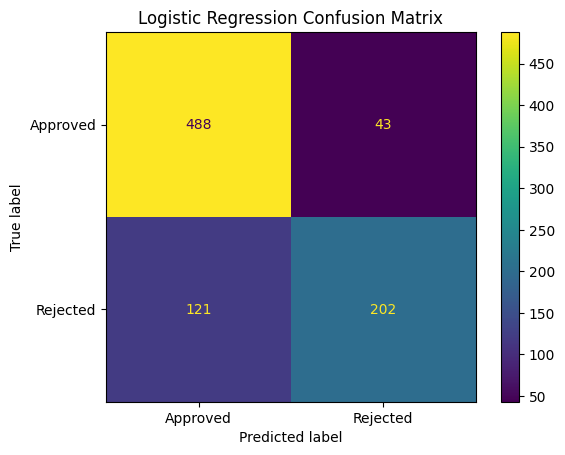

In [8]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [9]:
y_pred_proba = log_model.predict_proba(X_test)

print("First 5 probability rows:")
print(y_pred_proba[:5])

First 5 probability rows:
[[0.85083991 0.14916009]
 [0.96790283 0.03209717]
 [0.92648021 0.07351979]
 [0.7718699  0.2281301 ]
 [0.97946551 0.02053449]]


In [10]:
predicted_labels = target_encoder.inverse_transform(y_pred)
actual_labels = target_encoder.inverse_transform(y_test)

comparison_df = pd.DataFrame({
    "Actual": actual_labels,
    "Predicted": predicted_labels
})

comparison_df.head(10)

,Actual,Predicted
0,Approved,Approved
1,Approved,Approved
2,Approved,Approved
3,Rejected,Approved
4,Approved,Approved
5,Rejected,Rejected
6,Rejected,Approved
7,Approved,Approved
8,Approved,Approved
9,Approved,Approved


In [11]:
wrong_predictions = comparison_df[comparison_df["Actual"] != comparison_df["Predicted"]]
print("Number of wrong predictions:", len(wrong_predictions))
wrong_predictions.head(10)

Number of wrong predictions: 164


,Actual,Predicted
3,Rejected,Approved
6,Rejected,Approved
14,Rejected,Approved
18,Rejected,Approved
29,Rejected,Approved
31,Rejected,Approved
36,Rejected,Approved
44,Rejected,Approved
49,Rejected,Approved
50,Rejected,Approved


## Step 4 observations

- Trained a Logistic Regression baseline model.
- Evaluated the model using accuracy, classification report, and confusion matrix.
- This model serves as the first benchmark for future models.
- Since the target labels were encoded as:
  - Approved = 0
  - Rejected = 1
  the confusion matrix and predictions should be interpreted with that mapping in mind.
- Next, I will compare this baseline against stronger models such as Random Forest.